# Aula 10 - Feature Engineering para Séries Temporais

Nesta aula, vamos transformar uma série de vendas diárias em uma tabela adequada para modelos de Machine Learning. O cenário é uma rede varejista que precisa decidir hoje quanto pedir para entrega **daqui a 7 dias (D+7)**.

Ao final, você será capaz de:

- criar *lags* sem usar informações indisponíveis no momento da previsão;
- resumir o histórico com janelas móveis;
- criar variáveis de calendário e representações cíclicas;
- separar treino e teste respeitando o tempo;
- treinar e avaliar um modelo Random Forest;
- interpretar a importância das variáveis.

## 1. O problema de negócio

Modelos como AR, SARIMAX e Holt-Winters trabalham diretamente com a série temporal. Modelos tradicionais de Machine Learning, por outro lado, esperam uma tabela: cada linha é uma observação e cada coluna é uma variável explicativa.

**Feature Engineering** é o processo de criar essas colunas a partir dos dados brutos. Em séries temporais, lags, janelas móveis e calendário fornecem a “memória” que o modelo precisa.

A pergunta desta aula é: usando apenas as vendas conhecidas até hoje, quantas unidades devemos pedir para entrega exatamente daqui a sete dias?

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda valor: f'{valor:,.3f}')

RANDOM_STATE = 42
HORIZONTE = 7

## 2. Carregamento e inspeção dos dados

A planilha deve estar na mesma pasta deste notebook. Vamos converter a coluna `data` para data, ordenar cronologicamente e usá-la como índice.

In [2]:
arquivo = Path('dados_aula12_vendas.xlsx')
if not arquivo.exists():
    raise FileNotFoundError(
        f'Arquivo não encontrado: {arquivo.resolve()}. '
        'Coloque a planilha na mesma pasta do notebook.'
    )

df = pd.read_excel(arquivo, parse_dates=['data'])
df = df.sort_values('data').set_index('data')

print(f'Período: {df.index.min().date()} a {df.index.max().date()}')
print(f'Observações: {len(df):,}')
print(f'Datas duplicadas: {df.index.duplicated().sum()}')
print(f'Valores ausentes em vendas: {df["vendas"].isna().sum()}')
display(df.head())

Período: 2024-01-01 a 2025-12-30
Observações: 730
Datas duplicadas: 0
Valores ausentes em vendas: 0


,vendas
data,
2024-01-01,425.000
2024-01-02,473.853
2024-01-03,483.068
2024-01-04,505.683
2024-01-05,559.650


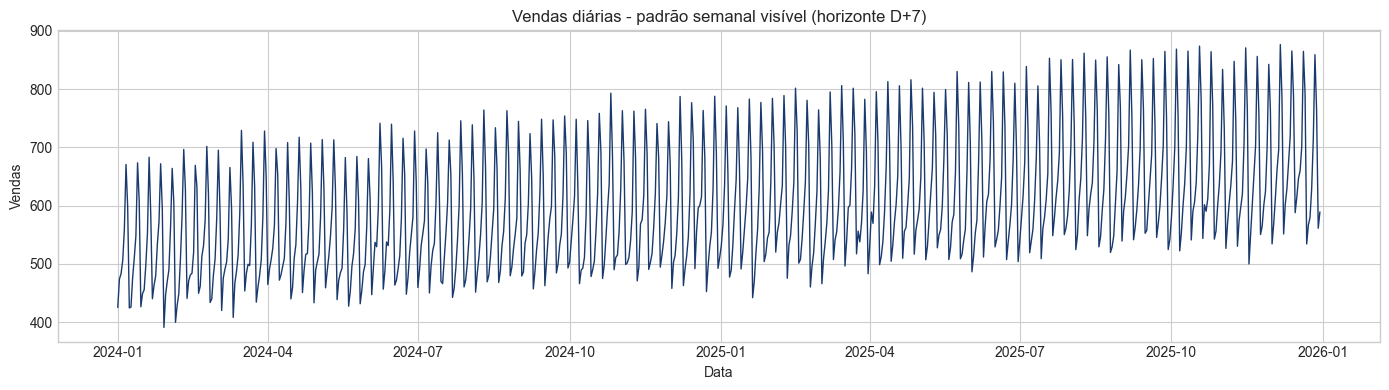

In [3]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df.index, df['vendas'], color='#1a3a6e', linewidth=1)
ax.set(
    title=f'Vendas diárias - padrão semanal visível (horizonte D+{HORIZONTE})',
    xlabel='Data',
    ylabel='Vendas',
)
plt.tight_layout()
plt.show()

## 3. Lag features: criando memória para o modelo

Uma *lag feature* representa um valor anterior da própria série. `lag_k` é o valor observado `k` períodos atrás.

Como a previsão é feita para D+7, o menor lag seguro é `lag_7`. Na linha do dia que queremos prever, `shift(7)` coloca a venda conhecida sete dias antes. Usar `lag_1` a `lag_6` vazaria informações que ainda não estariam disponíveis no momento do pedido.

Além dos lags semanais, criaremos **todos os lags intermediários válidos de 7 a 28**, como solicitado no material. Eles enriquecem o histórico recente e podem ajudar o modelo a inferir mudanças de nível e tendência.

In [4]:
feat = pd.DataFrame(index=df.index)
feat['y'] = df['vendas']

for lag in range(HORIZONTE, 29):
    feat[f'lag_{lag}'] = df['vendas'].shift(lag)

colunas_exemplo = ['y', 'lag_7', 'lag_8', 'lag_14', 'lag_21', 'lag_28']
display(feat[colunas_exemplo].tail(8))

,y,lag_7,lag_8,lag_14,lag_21,lag_28
data,,,,,,
2025-12-23,566.567,614.062,587.845,602.338,568.716,564.557
2025-12-24,579.242,646.428,614.062,628.968,612.923,600.897
2025-12-25,628.236,659.778,646.428,673.425,661.084,624.275
2025-12-26,713.893,701.306,659.778,719.028,695.444,700.156
2025-12-27,859.147,864.836,701.306,865.505,876.545,842.563
2025-12-28,763.263,792.851,864.836,788.831,785.562,762.063
2025-12-29,561.140,534.098,792.851,587.845,551.271,534.157
2025-12-30,589.050,566.567,534.098,614.062,602.338,568.716


## 4. Rolling features: resumindo o histórico

Janelas móveis calculam estatísticas sobre vários valores anteriores. A média representa o nível recente; o desvio padrão, a volatilidade; e mínimo e máximo ajudam a identificar extremos.

O passo crucial é usar `shift(HORIZONTE)` **antes** de `rolling(...)`. Assim, a janela termina na última informação que realmente existia quando a previsão D+7 foi feita.

In [5]:
historico_disponivel = df['vendas'].shift(HORIZONTE)

for janela in [7, 14, 28]:
    rolling = historico_disponivel.rolling(janela)
    feat[f'roll_mean_{janela}'] = rolling.mean()
    feat[f'roll_std_{janela}'] = rolling.std()
    feat[f'roll_min_{janela}'] = rolling.min()
    feat[f'roll_max_{janela}'] = rolling.max()

display(feat[['y', 'roll_mean_7', 'roll_std_7', 'roll_mean_28']].tail(8))

,y,roll_mean_7,roll_std_7,roll_mean_28
data,,,,
2025-12-23,566.567,696.809,101.069,677.949
2025-12-24,579.242,699.303,99.316,679.550
2025-12-25,628.236,697.354,100.040,679.801
2025-12-26,713.893,694.822,99.623,679.731
2025-12-27,859.147,694.726,99.432,680.040
2025-12-28,763.263,695.301,100.076,681.277
2025-12-29,561.140,687.623,111.144,680.697
2025-12-30,589.050,680.838,117.643,680.769


## 5. Features de calendário

Variáveis de calendário são conhecidas antecipadamente, inclusive em datas futuras. Dia da semana, mês, trimestre e fim de semana permitem ao modelo reconhecer padrões recorrentes da demanda.

In [6]:
feat['dow'] = feat.index.dayofweek
feat['day'] = feat.index.day
feat['month'] = feat.index.month
feat['quarter'] = feat.index.quarter
feat['is_weekend'] = (feat['dow'] >= 5).astype(int)

display(feat[['dow', 'day', 'month', 'quarter', 'is_weekend']].tail(8))

,dow,day,month,quarter,is_weekend
data,,,,,
2025-12-23,1,23,12,4,0
2025-12-24,2,24,12,4,0
2025-12-25,3,25,12,4,0
2025-12-26,4,26,12,4,0
2025-12-27,5,27,12,4,1
2025-12-28,6,28,12,4,1
2025-12-29,0,29,12,4,0
2025-12-30,1,30,12,4,0


## 6. Encoding cíclico

Algumas variáveis de calendário são circulares. Domingo (`6`) e segunda-feira (`0`) são próximos no tempo, embora numericamente pareçam distantes. Seno e cosseno transformam cada posição em um ponto do círculo unitário. O par `sin + cos` identifica corretamente cada posição do ciclo.

In [ ]:
feat['dow_sin'] = np.sin(2 * np.pi * feat['dow'] / 7)
feat['dow_cos'] = np.cos(2 * np.pi * feat['dow'] / 7)
feat['month_sin'] = np.sin(2 * np.pi * feat['month'] / 12)
feat['month_cos'] = np.cos(2 * np.pi * feat['month'] / 12)

display(feat[['dow', 'dow_sin', 'dow_cos', 'month', 'month_sin', 'month_cos']].tail(8))

,dow,dow_sin,dow_cos,month,month_sin,month_cos
data,,,,,,
2025-12-23,1,0.782,0.623,12,-0.000,1.000
2025-12-24,2,0.975,-0.223,12,-0.000,1.000
2025-12-25,3,0.434,-0.901,12,-0.000,1.000
2025-12-26,4,-0.434,-0.901,12,-0.000,1.000
2025-12-27,5,-0.975,-0.223,12,-0.000,1.000
2025-12-28,6,-0.782,0.623,12,-0.000,1.000
2025-12-29,0,0.000,1.000,12,-0.000,1.000
2025-12-30,1,0.782,0.623,12,-0.000,1.000


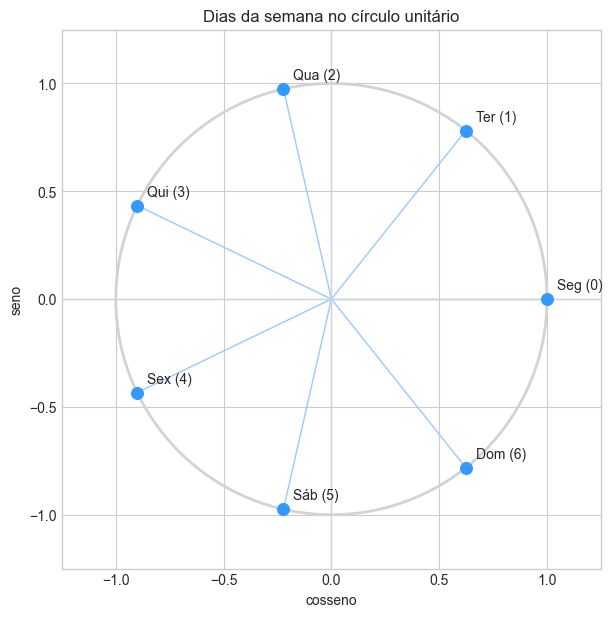

In [ ]:
dias = np.arange(7)
senos = np.sin(2 * np.pi * dias / 7)
cossenos = np.cos(2 * np.pi * dias / 7)
nomes = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']

fig, ax = plt.subplots(figsize=(7, 7))
circulo = plt.Circle((0, 0), 1, fill=False, color='lightgray', linewidth=2)
ax.add_patch(circulo)
ax.scatter(cossenos, senos, color='#3399ff', s=70, zorder=3)
for dia, nome, x, y in zip(dias, nomes, cossenos, senos):
    ax.annotate(f'{nome} ({dia})', (x, y), xytext=(7, 7), textcoords='offset points')
    ax.plot([0, x], [0, y], color='#9bc9ff', linewidth=1)
ax.axhline(0, color='lightgray', linewidth=1)
ax.axvline(0, color='lightgray', linewidth=1)
ax.set(
    xlim=(-1.25, 1.25), ylim=(-1.25, 1.25), aspect='equal',
    xlabel='cosseno', ylabel='seno', title='Dias da semana no círculo unitário'
)
plt.show()

## 7. Construção da tabela final

Lags e janelas móveis criam valores `NaN` no início da série, pois ainda não há histórico suficiente. A maior exigência de histórico determina quantas linhas iniciais serão perdidas. Removeremos somente as linhas incompletas depois de criar todas as features.

In [11]:
linhas_antes = len(feat)
feat_clean = feat.dropna().copy()
linhas_depois = len(feat_clean)
perdidas = linhas_antes - linhas_depois

print(f'Linhas antes do dropna: {linhas_antes}')
print(f'Linhas depois do dropna: {linhas_depois}')
print(f'Perdidas no aquecimento das janelas: {perdidas} ({perdidas / linhas_antes:.1%} da série)')
print(f'Total de features: {feat_clean.shape[1] - 1}')
display(feat_clean.head())

Linhas antes do dropna: 730
Linhas depois do dropna: 696
Perdidas no aquecimento das janelas: 34 (4.7% da série)
Total de features: 43


,y,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,lag_13,lag_14,lag_15,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,lag_25,lag_26,lag_27,lag_28,roll_mean_7,roll_std_7,roll_min_7,roll_max_7,roll_mean_14,roll_std_14,roll_min_14,roll_max_14,roll_mean_28,roll_std_28,roll_min_28,roll_max_28,dow,day,month,quarter,is_weekend,dow_sin,dow_cos,month_sin,month_cos
data,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-02-04,603.739,594.707,671.744,572.044,533.307,479.432,463.001,439.950,585.218,683.029,552.256,497.577,455.319,448.673,426.271,607.346,673.436,548.331,509.719,475.517,425.666,424.142,598.032,536.312,82.596,439.950,671.744,528.752,84.195,426.271,683.029,527.949,83.148,424.142,683.029,6,4,2,1,1,-0.782,0.623,0.866,0.500
2024-02-05,399.426,390.685,594.707,671.744,572.044,533.307,479.432,463.001,439.950,585.218,683.029,552.256,497.577,455.319,448.673,426.271,607.346,673.436,548.331,509.719,475.517,425.666,424.142,529.274,93.549,390.685,671.744,526.210,87.979,390.685,683.029,526.723,84.955,390.685,683.029,0,5,2,1,0,0.000,1.000,0.866,0.500
2024-02-06,428.379,446.534,390.685,594.707,671.744,572.044,533.307,479.432,463.001,439.950,585.218,683.029,552.256,497.577,455.319,448.673,426.271,607.346,673.436,548.331,509.719,475.517,425.666,526.922,95.676,390.685,671.744,526.057,88.126,390.685,683.029,525.747,85.738,390.685,683.029,1,6,2,1,0,0.782,0.623,0.866,0.500
2024-02-07,448.401,469.732,446.534,390.685,594.707,671.744,572.044,533.307,479.432,463.001,439.950,585.218,683.029,552.256,497.577,455.319,448.673,426.271,607.346,673.436,548.331,509.719,475.517,525.536,96.545,390.685,671.744,527.087,87.316,390.685,683.029,525.271,86.020,390.685,683.029,2,7,2,1,0,0.975,-0.223,0.866,0.500
2024-02-08,507.988,489.304,469.732,446.534,390.685,594.707,671.744,572.044,533.307,479.432,463.001,439.950,585.218,683.029,552.256,497.577,455.319,448.673,426.271,607.346,673.436,548.331,509.719,519.250,97.383,390.685,671.744,526.496,87.559,390.685,683.029,524.686,86.214,390.685,683.029,3,8,2,1,0,0.434,-0.901,0.866,0.500


## 8. Divisão treino-teste

A ordem cronológica deve ser preservada. O treino contém as observações mais antigas e o teste, os 60 dias mais recentes. Não há embaralhamento. Esse teste simula um modelo fixo produzindo previsões diárias para D+7 em um período ainda não visto.

In [12]:
test_size = 60
train = feat_clean.iloc[:-test_size].copy()
test = feat_clean.iloc[-test_size:].copy()
feature_cols = [col for col in feat_clean.columns if col != 'y']

print(f'Treino: {len(train)} dias | Teste: {len(test)} dias')
print(f'Treino: {train.index.min().date()} a {train.index.max().date()}')
print(f'Teste:  {test.index.min().date()} a {test.index.max().date()}')
print(f'Features construídas ({len(feature_cols)}): {feature_cols}')

Treino: 636 dias | Teste: 60 dias
Treino: 2024-02-04 a 2025-10-31
Teste:  2025-11-01 a 2025-12-30
Features construídas (43): ['lag_7', 'lag_8', 'lag_9', 'lag_10', 'lag_11', 'lag_12', 'lag_13', 'lag_14', 'lag_15', 'lag_16', 'lag_17', 'lag_18', 'lag_19', 'lag_20', 'lag_21', 'lag_22', 'lag_23', 'lag_24', 'lag_25', 'lag_26', 'lag_27', 'lag_28', 'roll_mean_7', 'roll_std_7', 'roll_min_7', 'roll_max_7', 'roll_mean_14', 'roll_std_14', 'roll_min_14', 'roll_max_14', 'roll_mean_28', 'roll_std_28', 'roll_min_28', 'roll_max_28', 'dow', 'day', 'month', 'quarter', 'is_weekend', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']


## 9. Modelo de Machine Learning: Random Forest

`X` contém as features criadas e `y` contém as vendas que desejamos prever. O Random Forest combina várias árvores de decisão para aprender relações não lineares entre o histórico, o calendário e o alvo.

In [13]:
modelo = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
modelo.fit(train[feature_cols], train['y'])
previsoes = modelo.predict(test[feature_cols])

mae = mean_absolute_error(test['y'], previsoes)
rmse = np.sqrt(mean_squared_error(test['y'], previsoes))
mape = mean_absolute_percentage_error(test['y'], previsoes)

print(f'MAE:  {mae:,.2f} unidades')
print(f'RMSE: {rmse:,.2f} unidades')
print(f'MAPE: {mape:.2%}')

MAE:  15.60 unidades
RMSE: 20.15 unidades
MAPE: 2.41%


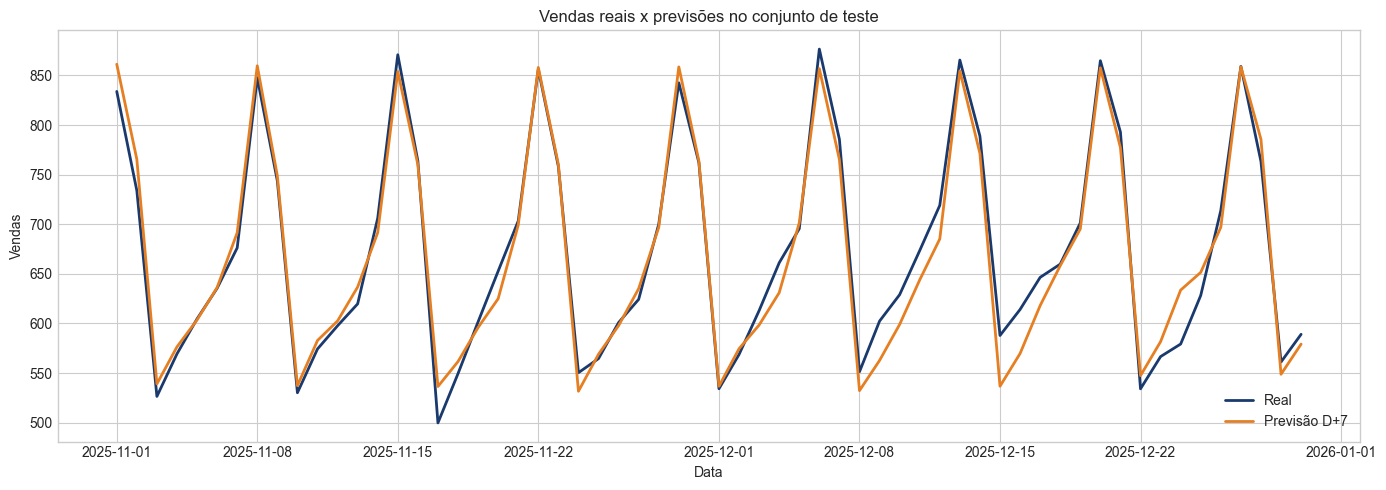

,real,previsao
data,,
2025-11-01,833.847,861.298
2025-11-02,733.882,765.450
2025-11-03,526.440,539.091
2025-11-04,569.330,576.428
2025-11-05,604.593,603.532
2025-11-06,635.473,636.234
2025-11-07,676.192,691.500
2025-11-08,847.651,859.744
2025-11-09,743.709,748.774


In [14]:
resultado = pd.DataFrame({'real': test['y'], 'previsao': previsoes}, index=test.index)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(resultado.index, resultado['real'], label='Real', color='#1a3a6e', linewidth=2)
ax.plot(resultado.index, resultado['previsao'], label='Previsão D+7', color='#e67e22', linewidth=2)
ax.set(title='Vendas reais x previsões no conjunto de teste', xlabel='Data', ylabel='Vendas')
ax.legend()
plt.tight_layout()
plt.show()
display(resultado.head(10))

## 10. Importância das features

A importância indica quanto cada feature foi utilizada pelas árvores. Valores maiores representam maior contribuição para as decisões do modelo. Features correlacionadas podem dividir a importância entre si; portanto, importância não significa causalidade e pode mudar em outra série ou modelo.

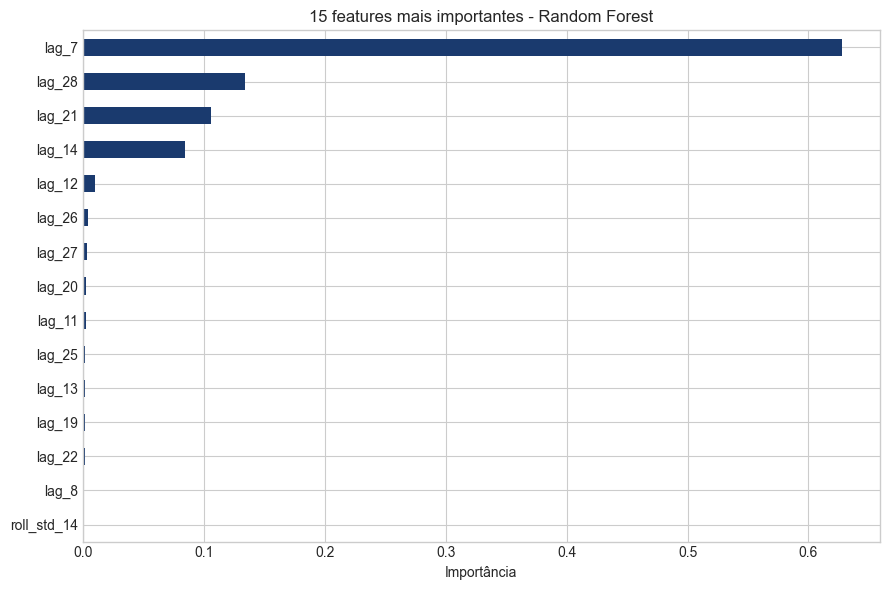

,importancia
lag_7,0.628
lag_28,0.134
lag_21,0.106
lag_14,0.085
lag_12,0.010
lag_26,0.004
lag_27,0.003
lag_20,0.002
lag_11,0.002
lag_25,0.002


In [17]:
importancias = pd.Series(
    modelo.feature_importances_, index=feature_cols, name='importancia'
).sort_values(ascending=False)

top_15 = importancias.head(15).sort_values()
fig, ax = plt.subplots(figsize=(9, 6))
top_15.plot(kind='barh', ax=ax, color='#1a3a6e')
ax.set(title='15 features mais importantes - Random Forest', xlabel='Importância', ylabel='')
plt.tight_layout()
plt.show()

display(importancias.round(4).to_frame())